# Data Understanding

In [ ]:

import numpy as np
import pandas as pd
!pip install --upgrade gdown

import gdown
file_id="11wu0cUzEceRjfp7GJK39cPSfqa5hzUiC"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "train.csv",quiet=False)

a=pd.read_csv("train.csv")
a.head()

Downloading...
From: https://drive.google.com/uc?id=11wu0cUzEceRjfp7GJK39cPSfqa5hzUiC
To: /content/train.csv
100%|██████████| 2.29M/2.29M [00:00<00:00, 184MB/s]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Check dataset shape
a.shape

(9994, 21)

In [ ]:
# Numerical columns
nc=a.select_dtypes(include=np.number).columns
a[nc].describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
# Category columns
c=a.select_dtypes(include=["object","category"]).columns
a[c].describe()


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [ ]:
a["Order Date"] = pd.to_datetime(a["Order Date"])
a["Ship Date"] = pd.to_datetime(a["Ship Date"])

dc = a.select_dtypes(include=["datetime"]).columns
print(dc)

a[dc].describe()

Index(['Order Date', 'Ship Date'], dtype='object')


,Order Date,Ship Date
count,9994,9994
mean,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912
min,2014-01-03 00:00:00,2014-01-07 00:00:00
25%,2015-05-23 00:00:00,2015-05-27 00:00:00
50%,2016-06-26 00:00:00,2016-06-29 00:00:00
75%,2017-05-14 00:00:00,2017-05-18 00:00:00
max,2017-12-30 00:00:00,2018-01-05 00:00:00


In [ ]:
a.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


## NUMPY ANALYSIS

In [ ]:
# Mean of sales

a["Sales"].mean()        # sum of all values/no.of values


np.float64(229.85800083049833)

In [ ]:
# Median of profit

a["Profit"].median()

8.6665

In [ ]:
# Standard deviation

a.std(numeric_only=True)

,0
Row ID,2885.163629
Postal Code,32063.693350
Sales,623.245101
Quantity,2.225110
Discount,0.206452
Profit,234.260108


In [ ]:
# Unsual values     # using INTER QUARTILE RANGE

num_cols = a.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
  q1=a[col].quantile(0.25)
  q3=a[col].quantile(0.75)

  IQR=q3-q1
  lower_bound=q1-1.5*IQR
  upper_bound=q3+1.5*IQR

  outliers = a[(a[col] < lower_bound) | (a[col] > upper_bound)]

  print(f"\nColumn: {col}")
  print(f"Number of unusual values: {len(outliers)}")
  print(outliers[[col]].head())


Column: Row ID
Number of unusual values: 0
Empty DataFrame
Columns: [Row ID]
Index: []

Column: Postal Code
Number of unusual values: 0
Empty DataFrame
Columns: [Postal Code]
Index: []

Column: Sales
Number of unusual values: 1167
        Sales
1    731.9400
3    957.5775
7    907.1520
10  1706.1840
11   911.4240

Column: Quantity
Number of unusual values: 170
     Quantity
113        14
139        14
147        11
251        13
329        10

Column: Discount
Number of unusual values: 856
    Discount
14       0.8
15       0.8
28       0.7
32       0.7
36       0.6

Column: Profit
Number of unusual values: 1881
      Profit
1   219.5820
3  -383.0310
7    90.7152
10   85.3092
13  132.5922


In [ ]:
a.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


# DATA TYPE CONVERSION

In [ ]:
# Convert:
#Order Date → datetime
#Ship Date → datetime
a["Order Date"]=pd.to_datetime(a["Order Date"])
a["Ship Date"]=pd.to_datetime(a["Ship Date"])



In [ ]:
a[["Order Date","Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


# MISSING VALUES

In [ ]:
a.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


There are no missing values

REMOVE  IRRELEVANT COLUMNS

In [ ]:
a.drop("Row ID",axis=1,inplace=True)

In [ ]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Order Date     9994 non-null   datetime64[ns]
 2   Ship Date      9994 non-null   datetime64[ns]
 3   Ship Mode      9994 non-null   object        
 4   Customer ID    9994 non-null   object        
 5   Customer Name  9994 non-null   object        
 6   Segment        9994 non-null   object        
 7   Country        9994 non-null   object        
 8   City           9994 non-null   object        
 9   State          9994 non-null   object        
 10  Postal Code    9994 non-null   int64         
 11  Region         9994 non-null   object        
 12  Product ID     9994 non-null   object        
 13  Category       9994 non-null   object        
 14  Sub-Category   9994 non-null   object        
 15  Product Name   9994 n

REMOVE DUPLICATES

In [ ]:
a.drop_duplicates(inplace=True)

In [ ]:
a.describe().columns

Index(['Order Date', 'Ship Date', 'Postal Code', 'Sales', 'Quantity',
       'Discount', 'Profit'],
      dtype='object')

 Categorical Cleaning


In [ ]:
a['Category'] = a['Category'].str.strip()
a['Category'] = a['Category'].str.title()

In [ ]:
a['Sub-Category'] = a['Sub-Category'].str.strip()
a['Sub-Category'] = a['Sub-Category'].str.title()

In [ ]:
a['Region'] = a['Region'].str.strip()
a['Region'] =a['Region'].str.title()



a['Region'] = a['Region'].replace({
    'South ': 'South',
    'SOUTH': 'South',
    'soth': 'South'
})

In [ ]:
print(a['Category'].unique())
print(a['Sub-Category'].unique())
print(a['Region'].unique())

['Furniture' 'Office Supplies' 'Technology']
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']
['South' 'West' 'Central' 'East']


# Date Feature Engineering

In [ ]:
a["Order Year"] = a["Order Date"].dt.year
a["Order Month"] = a["Order Date"].dt.month
a["Order Day"] = a["Order Date"].dt.day

In [ ]:
print(a[["Order Year", "Order Month", "Order Day"]].head())

   Order Year  Order Month  Order Day
0        2016           11          8
1        2016           11          8
2        2016            6         12
3        2015           10         11
4        2015           10         11


In [ ]:
a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9993 non-null   object        
 1   Order Date     9993 non-null   datetime64[ns]
 2   Ship Date      9993 non-null   datetime64[ns]
 3   Ship Mode      9993 non-null   object        
 4   Customer ID    9993 non-null   object        
 5   Customer Name  9993 non-null   object        
 6   Segment        9993 non-null   object        
 7   Country        9993 non-null   object        
 8   City           9993 non-null   object        
 9   State          9993 non-null   object        
 10  Postal Code    9993 non-null   int64         
 11  Region         9993 non-null   object        
 12  Product ID     9993 non-null   object        
 13  Category       9993 non-null   object        
 14  Sub-Category   9993 non-null   object        
 15  Product Name   9993 non-nu

# Delivery Time

In [ ]:
a["Delivery Days"] = (a["Ship Date"] - a["Order Date"]).dt.days

In [ ]:
print(a["Delivery Days"])

0       3
1       3
2       4
3       7
4       7
       ..
9989    2
9990    5
9991    5
9992    5
9993    5
Name: Delivery Days, Length: 9993, dtype: int64


In [ ]:
(a["Delivery Days"] < 0).sum()

np.int64(0)

# Outlier Detection

In [ ]:
cols = ["Sales", "Profit", "Quantity", "Discount"]

for col in cols:
    Q1 = a[col].quantile(0.25)
    Q3 = a[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = a[(a[col] < lower_bound) | (a[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"Number of outliers: {len(outliers)}")
    print(outliers[[col]].head())



Column: Sales
Number of outliers: 1167
        Sales
1    731.9400
3    957.5775
7    907.1520
10  1706.1840
11   911.4240

Column: Profit
Number of outliers: 1881
      Profit
1   219.5820
3  -383.0310
7    90.7152
10   85.3092
13  132.5922

Column: Quantity
Number of outliers: 170
     Quantity
113        14
139        14
147        11
251        13
329        10

Column: Discount
Number of outliers: 856
    Discount
14       0.8
15       0.8
28       0.7
32       0.7
36       0.6


# Feature Engineering

In [ ]:
# PROFIT MARGIN

a["Profit Margin"]=a["Profit"]/a["Sales"]

In [ ]:
print(a["Profit Margin"])

0       0.1600
1       0.3000
2       0.4700
3      -0.4000
4       0.1125
         ...  
9989    0.1625
9990    0.1700
9991    0.0750
9992    0.4500
9993    0.3000
Name: Profit Margin, Length: 9993, dtype: float64


In [ ]:
a["Discount"].describe()

,Discount
count,9993.000000
mean,0.156188
std,0.206457
min,0.000000
25%,0.000000
50%,0.200000
75%,0.200000
max,0.800000


In [ ]:
a["Discount Category"] = "Low"

a.loc[a["Discount"] > 0, "Discount Category"] = "Medium"
a.loc[a["Discount"] > 0.2, "Discount Category"] = "High"

In [ ]:
print(a["Discount Category"].head())

0       Low
1       Low
2       Low
3      High
4    Medium
Name: Discount Category, dtype: object


In [ ]:
a["Sales"].describe()

,Sales
count,9993.000000
mean,229.852846
std,623.276074
min,0.444000
25%,17.280000
50%,54.480000
75%,209.940000
max,22638.480000


In [ ]:
a["Sales Category"] = "Low"

a.loc[a["Sales"] > 17.28, "Sales Category"] = "Medium"
a.loc[a["Sales"] > 209.94, "Sales Category"] = "High"

In [ ]:
a["Sales Category"]

,Sales Category
0,High
1,High
2,Low
3,High
4,Medium
...,...
9989,Medium
9990,Medium
9991,High
9992,Medium


# Final Validation



In [ ]:
print(a.isnull().sum())

Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Customer Name        0
Segment              0
Country              0
City                 0
State                0
Postal Code          0
Region               0
Product ID           0
Category             0
Sub-Category         0
Product Name         0
Sales                0
Quantity             0
Discount             0
Profit               0
Order Year           0
Order Month          0
Order Day            0
Delivery Days        0
Profit Margin        0
Discount Category    0
Sales Category       0
dtype: int64


In [ ]:
print(a.duplicated().sum())

0


In [ ]:
print(a.dtypes)

Order ID                     object
Order Date           datetime64[ns]
Ship Date            datetime64[ns]
Ship Mode                    object
Customer ID                  object
Customer Name                object
Segment                      object
Country                      object
City                         object
State                        object
Postal Code                   int64
Region                       object
Product ID                   object
Category                     object
Sub-Category                 object
Product Name                 object
Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Order Year                    int32
Order Month                   int32
Order Day                     int32
Delivery Days                 int64
Profit Margin               float64
Discount Category            object
Sales Category               object
dtype: object


In [ ]:
print(a[a["Sales"] <= 0])

Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit, Order Year, Order Month, Order Day, Delivery Days, Profit Margin, Discount Category, Sales Category]
Index: []

[0 rows x 27 columns]


In [ ]:
print(a["Discount Category"].value_counts())
print(a["Sales Category"].value_counts())

Discount Category
Low       4798
Medium    3803
High      1392
Name: count, dtype: int64
Sales Category
Medium    4995
Low       2501
High      2497
Name: count, dtype: int64


In [ ]:
print(a["Discount Category"].unique())
print(a["Sales Category"].unique())

['Low' 'High' 'Medium']
['High' 'Low' 'Medium']


In [ ]:
print(a.describe())

                          Order Date                      Ship Date  \
count                           9993                           9993   
mean   2016-04-30 01:53:33.089162240  2016-05-04 00:53:19.039327488   
min              2014-01-03 00:00:00            2014-01-07 00:00:00   
25%              2015-05-23 00:00:00            2015-05-27 00:00:00   
50%              2016-06-26 00:00:00            2016-06-29 00:00:00   
75%              2017-05-14 00:00:00            2017-05-18 00:00:00   
max              2017-12-30 00:00:00            2018-01-05 00:00:00   
std                              NaN                            NaN   

        Postal Code         Sales     Quantity     Discount       Profit  \
count   9993.000000   9993.000000  9993.000000  9993.000000  9993.000000   
mean   55191.576403    229.852846     3.789753     0.156188    28.660971   
min     1040.000000      0.444000     1.000000     0.000000 -6599.978000   
25%    23223.000000     17.280000     2.000000     0.000

# EXPLORATORY DATA ANALYSIS

In [ ]:
a["Sales"].sum()

np.float64(2296919.4883000003)

In [ ]:
a["Profit"].sum()

np.float64(286409.0805)

In [ ]:
print(len(a))

9993


In [ ]:
a[a.duplicated()]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Quantity,Discount,Profit,Order Year,Order Month,Order Day,Delivery Days,Profit Margin,Discount Category,Sales Category


# Univariate Analysis


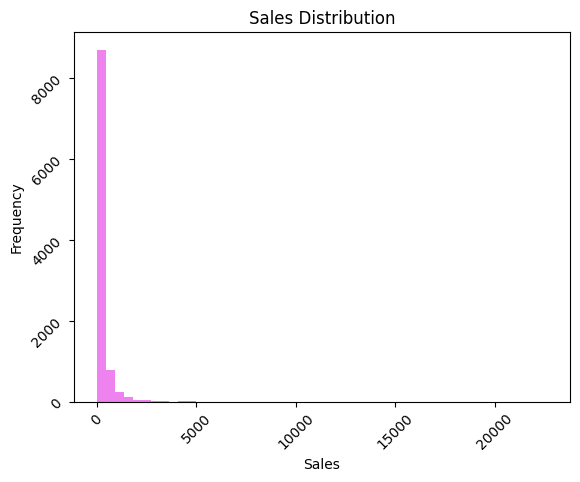

In [ ]:
import matplotlib.pyplot as plt
plt.hist(a["Sales"],bins=50,color="violet")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

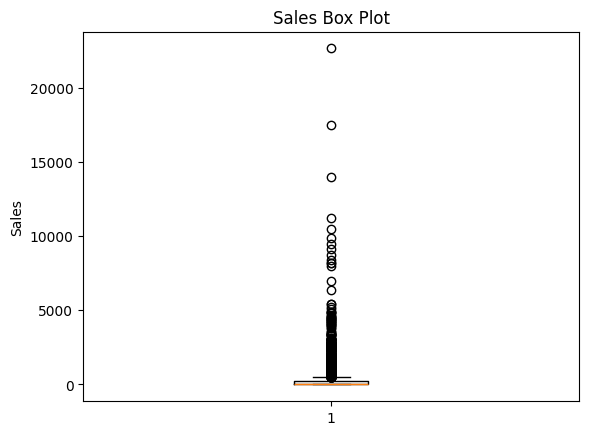

In [ ]:
plt.boxplot(a["Sales"])
plt.ylabel("Sales")
plt.title("Sales Box Plot")
plt.show()

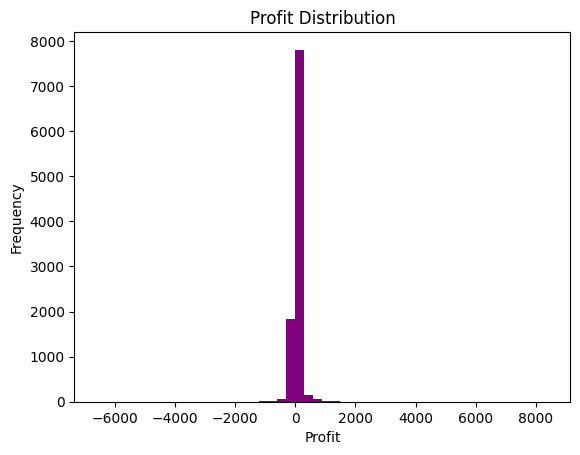

In [ ]:
plt.hist(a["Profit"],bins=50,color="purple")
plt.xlabel("Profit")
plt.title("Profit Distribution")
plt.ylabel("Frequency")
plt.show()

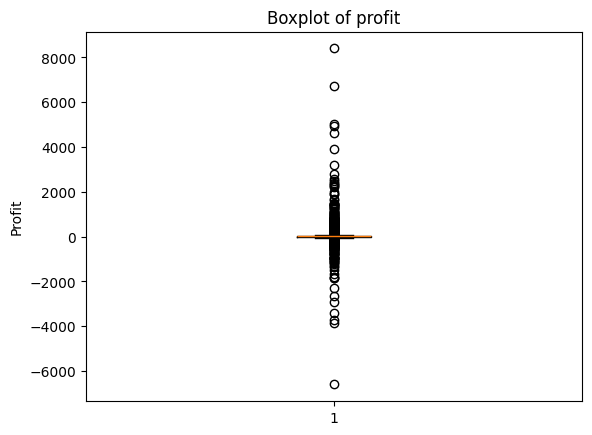

In [ ]:
plt.boxplot(a["Profit"])
plt.ylabel("Profit")
plt.title("Boxplot of profit")
plt.show()

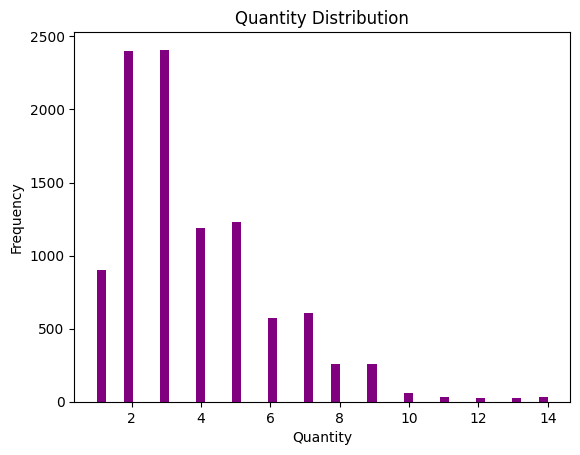

In [ ]:
plt.hist(a["Quantity"],bins=50,color="purple")
plt.xlabel("Quantity")
plt.title("Quantity Distribution")
plt.ylabel("Frequency")
plt.show()

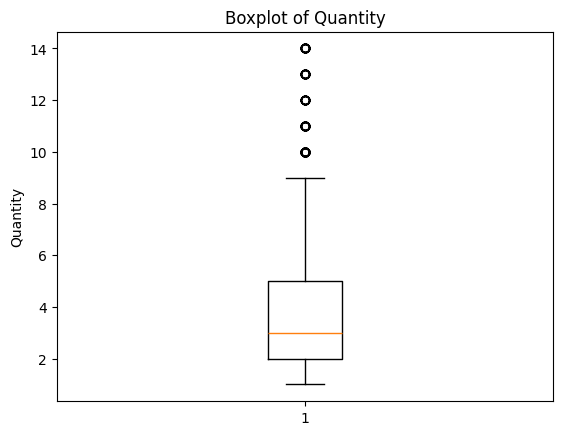

In [ ]:
plt.boxplot(a["Quantity"])
plt.ylabel("Quantity")
plt.title("Boxplot of Quantity")
plt.show()

# Category Analysis

Text(0.5, 1.0, 'Sales by Category')

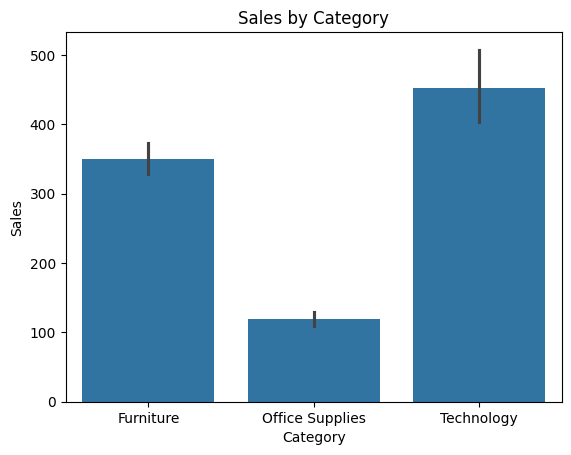

In [ ]:
import seaborn as sns
sns.barplot(x="Category",y="Sales",data=a)
plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Sales by Category")

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

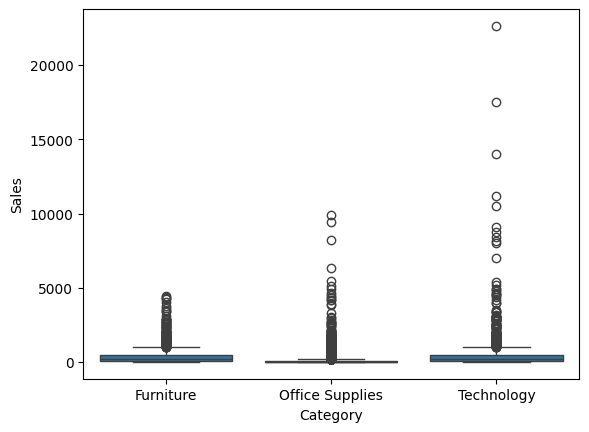

In [ ]:
sns.boxplot(x="Category",y="Sales",data=a)
plt.xlabel("Category")
plt.ylabel("Sales")
plt

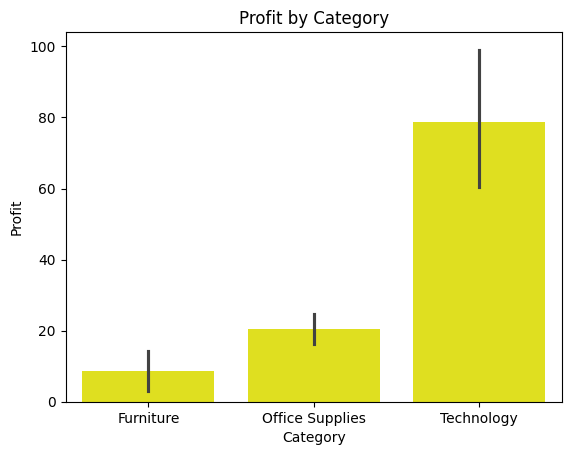

In [ ]:
sns.barplot(x="Category",y="Profit",data=a,color="yellow")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Profit by Category")
plt.show()

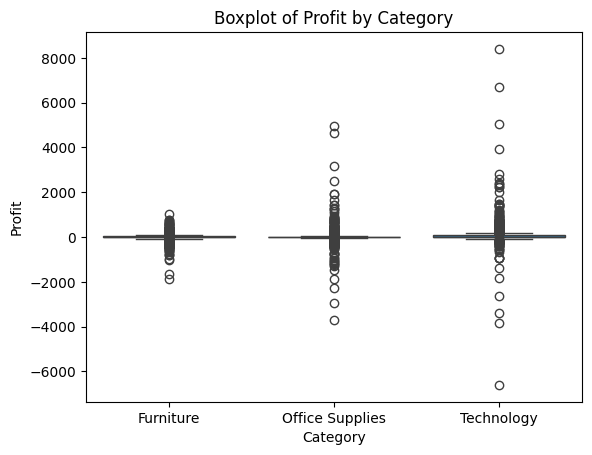

In [ ]:
sns.boxplot(x="Category",y="Profit",data=a)
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Boxplot of Profit by Category")
plt.show()

# Region Analysis

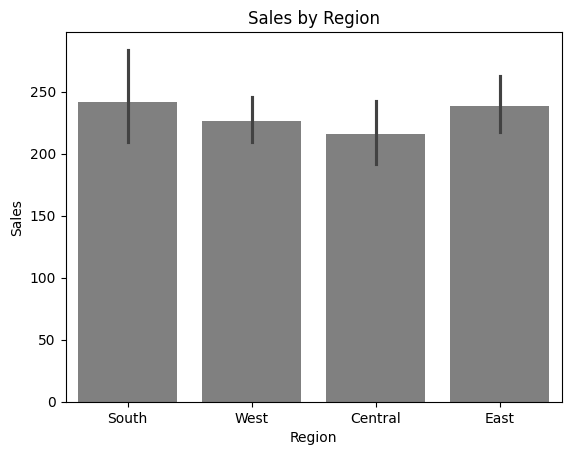

In [ ]:
sns.barplot(x="Region",y="Sales",data=a,color="grey")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Sales by Region")
plt.show()

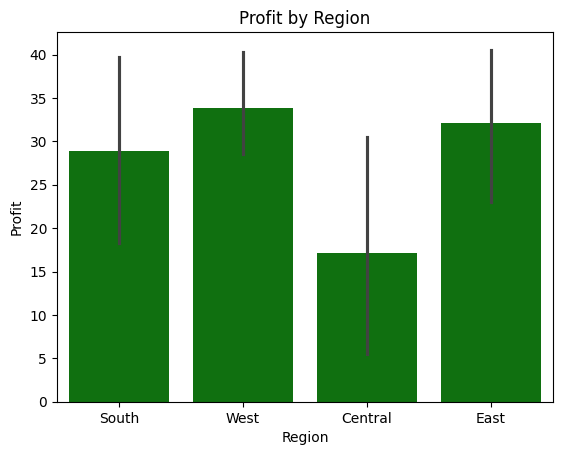

In [ ]:
sns.barplot(x="Region",y="Profit",data=a,color="green")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.title("Profit by Region")
plt.show()


Discount Impact

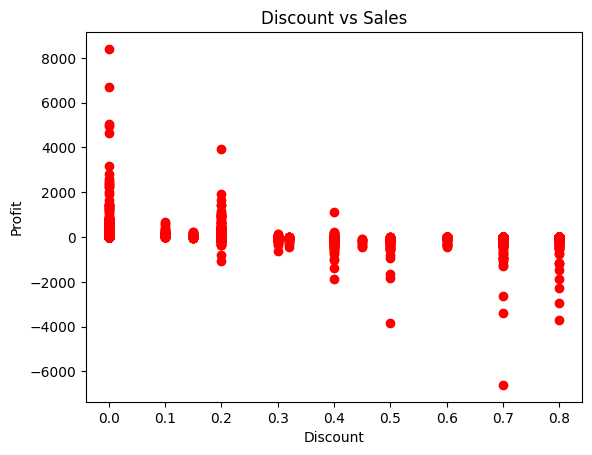

In [ ]:
plt.scatter(a["Discount"],a["Profit"],color="red")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Sales")
plt.show()

# Product Analysis

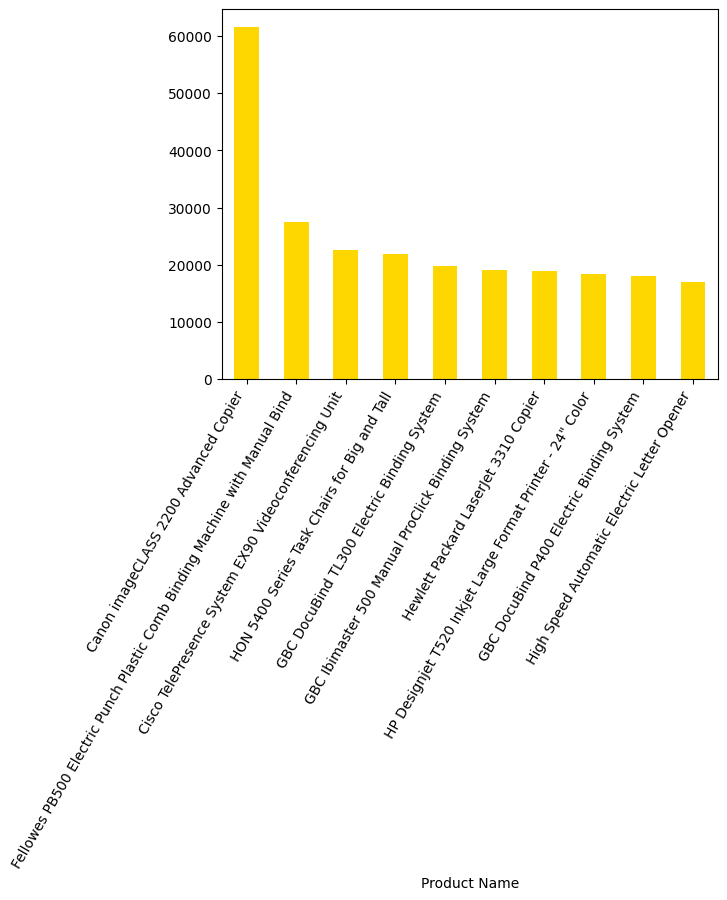

In [ ]:
a.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar",color="gold")
plt.xticks(rotation=60,ha="right")
plt.show()

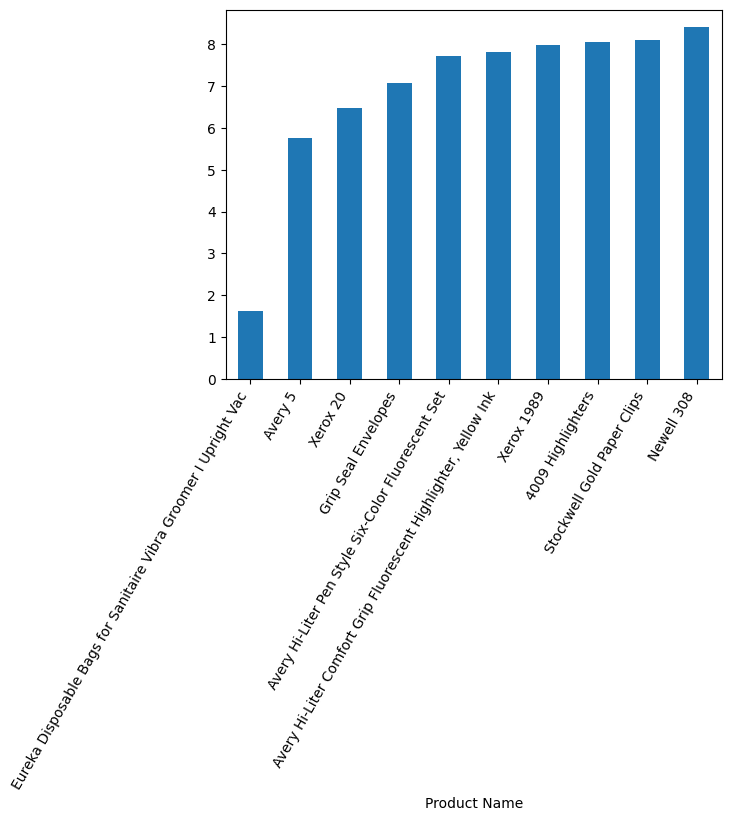

In [ ]:
a.groupby("Product Name")["Sales"].sum().sort_values().head(10).plot(kind="bar")
plt.xticks(rotation=60,ha="right")
plt.show()

Time Analysis

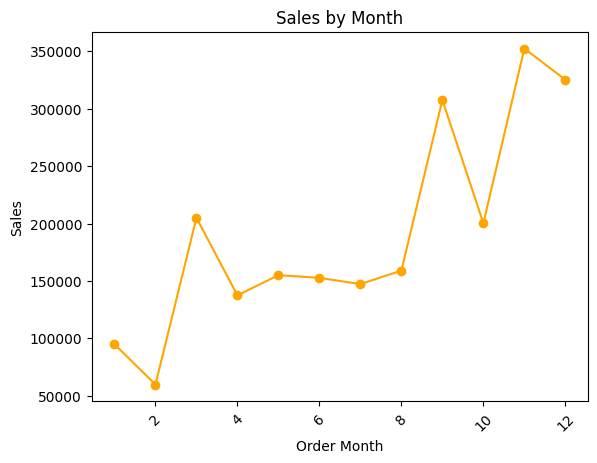

In [ ]:
a.groupby("Order Month")["Sales"].sum().plot(kind="line",color="orange",marker="o")
plt.xlabel("Order Month")
plt.ylabel("Sales")
plt.title("Sales by Month")
plt.xticks(rotation=45,ha="center")
plt.show()

Customer Segment Analysis

Text(0.5, 1.0, 'Sales by Segment')

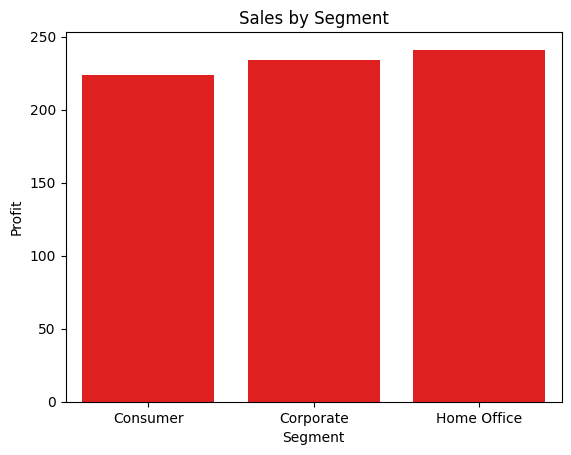

In [ ]:
sns.barplot(data=a, x="Segment", y="Sales", errorbar=None,color="red")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.title("Sales by Segment")

Text(0.5, 1.0, 'Profit by Segment')

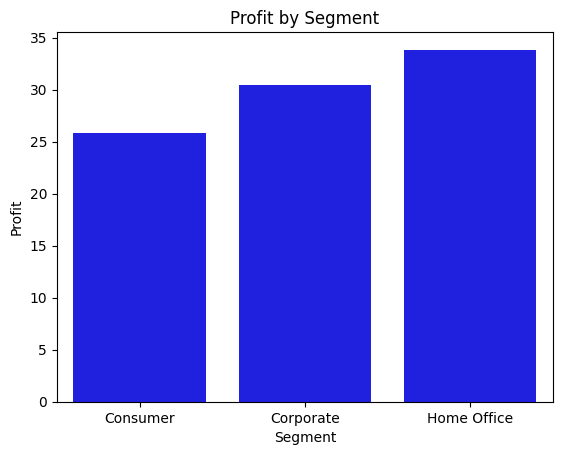

In [ ]:
sns.barplot(data=a, x="Segment", y="Profit", errorbar=None,color="blue")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.title("Profit by Segment")

<Axes: >

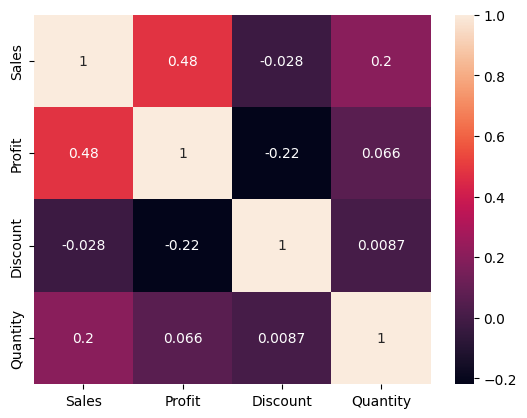

In [ ]:
sns.heatmap(a[["Sales","Profit","Discount","Quantity"]].corr(), annot=True)

# INSIGHT QUESTIONS

In [ ]:
a[["Sales","Profit"]].sum()

,0
Sales,2.296919e+06
Profit,2.864091e+05


In [ ]:
print(a["Order ID"].nunique())

5009


# Sales Analysis

In [ ]:
a.groupby("Category")["Sales"].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741718.4233
Office Supplies,719047.0320


In [ ]:
a.groupby("Category")["Profit"].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18463.3316


# Regional Insights

In [ ]:
a.groupby("Region")["Profit"].sum().sort_values(ascending=False)

,Profit
Region,
West,108418.4489
East,91534.8388
South,46749.4303
Central,39706.3625


In [ ]:
a.groupby("Region")["Profit"].sum().sort_values(ascending=True)

,Profit
Region,
Central,39706.3625
South,46749.4303
East,91534.8388
West,108418.4489


# Profitability

In [ ]:
a[a["Profit"] < 0].groupby("Product Name")["Profit"].sum().sort_values().head(10)

,Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-9239.9692
GBC DocuBind P400 Electric Binding System,-6859.3896
Lexmark MX611dhe Monochrome Laser Printer,-5269.9690
GBC Ibimaster 500 Manual ProClick Binding System,-5098.5660
GBC DocuBind TL300 Electric Binding System,-4162.0336
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,-3431.6730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-3107.5272
Ibico EPK-21 Electric Binding System,-2929.4845


<Axes: xlabel='Discount', ylabel='Profit'>

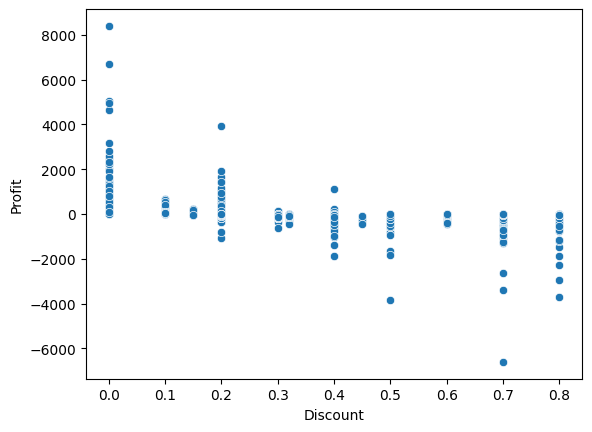

In [ ]:
sns.scatterplot(data=a, x="Discount", y="Profit")

# Customer Insights

In [ ]:
a.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.293718e+05


In [ ]:
a.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

,Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60310.7373


# Time-Based Insights

In [ ]:
a.describe().columns

Index(['Order Date', 'Ship Date', 'Postal Code', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Order Year', 'Order Month', 'Order Day',
       'Delivery Days', 'Profit Margin'],
      dtype='object')

In [ ]:
a.groupby("Order Month")["Sales"].sum().sort_values(ascending=False)

,Sales
Order Month,
11,352461.0710
12,325293.5035
9,307649.9457
3,205005.4888
10,200322.9847
8,159044.0630
5,155028.8117
6,152718.6793
7,147238.0970


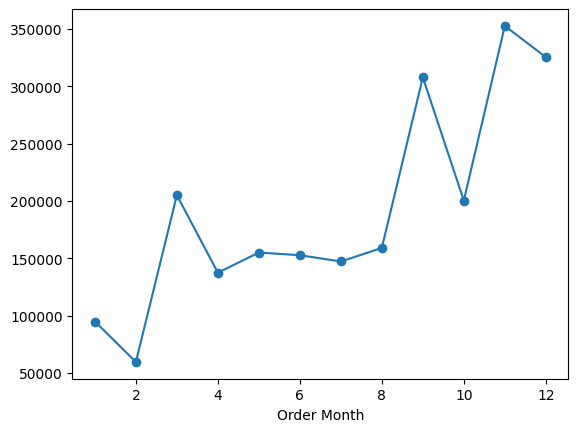

In [ ]:
a.groupby("Order Month")["Sales"].sum().plot(marker="o")
plt.show()

# Discount Insights

In [ ]:
a.groupby("Discount")["Profit"].mean()[
    a.groupby("Discount")["Profit"].mean() < 0
]

,Profit
Discount,
0.30,-45.828401
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456
0.60,-43.077212
0.70,-95.874060
0.80,-101.796797


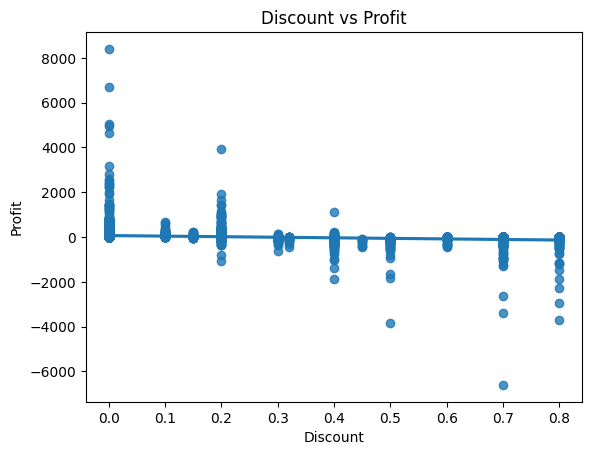

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=a, x="Discount", y="Profit")
plt.title("Discount vs Profit")
plt.show()

# No, high discounts are not justified.

# As discount increases, profit decreases
## Very high discounts often lead to losse

# Advanced Insights

In [ ]:
a.groupby("Category")["Profit"].sum().sort_values()

,Profit
Category,
Furniture,18463.3316
Office Supplies,122490.8008
Technology,145454.9481


In [ ]:
a.sort_values(by=["Sales","Profit"], ascending=[False, True]).head(5)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Quantity,Discount,Profit,Order Year,Order Month,Order Day,Delivery Days,Profit Margin,Discount Category,Sales Category
2697,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,...,6,0.5,-1811.0784,2014,3,18,5,-0.08,High,High
6826,CA-2016-118689,2016-10-02,2016-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,Indiana,...,5,0.0,8399.9760,2016,10,2,7,0.48,Low,High
8153,CA-2017-140151,2017-03-23,2017-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,Washington,...,4,0.0,6719.9808,2017,3,23,2,0.48,Low,High
2623,CA-2017-127180,2017-10-22,2017-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,New York,...,4,0.2,3919.9888,2017,10,22,2,0.35,Medium,High
4190,CA-2017-166709,2017-11-17,2017-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,Delaware,...,3,0.0,5039.9856,2017,11,17,5,0.48,Low,High


# Visualization Tasks

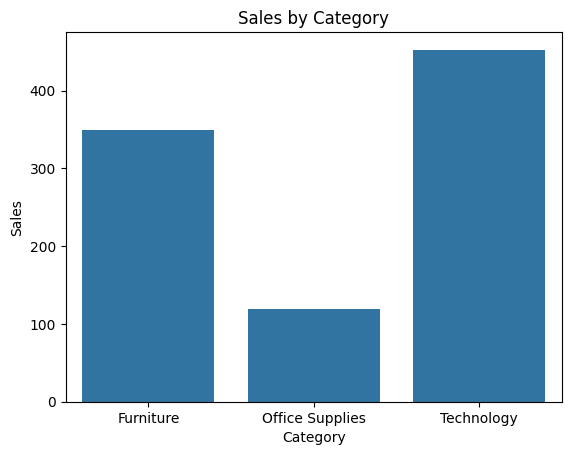

In [ ]:
sns.barplot(data=a, x="Category", y="Sales", errorbar=None)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

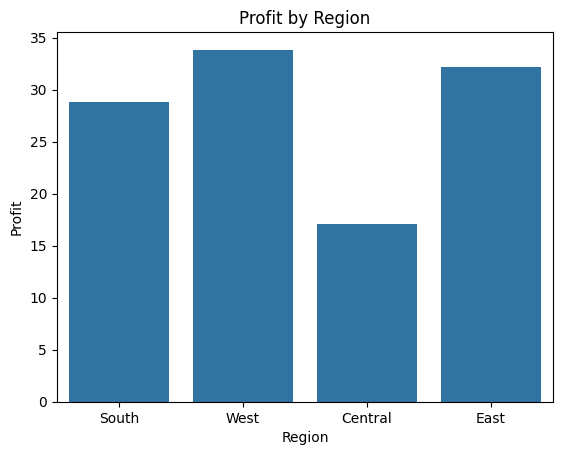

In [ ]:
sns.barplot(data=a, x="Region", y="Profit", errorbar=None)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

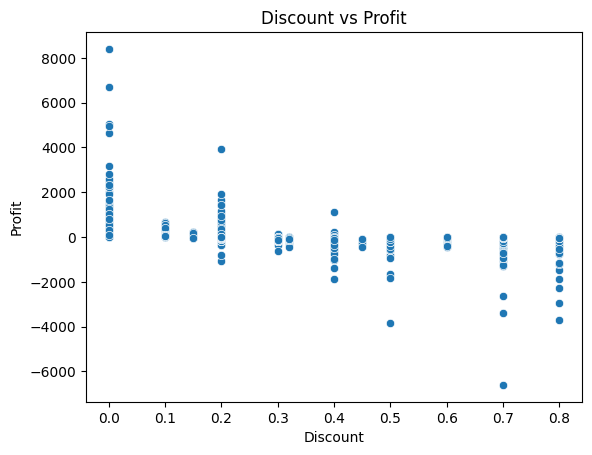

In [ ]:
sns.scatterplot(data=a, x="Discount", y="Profit")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

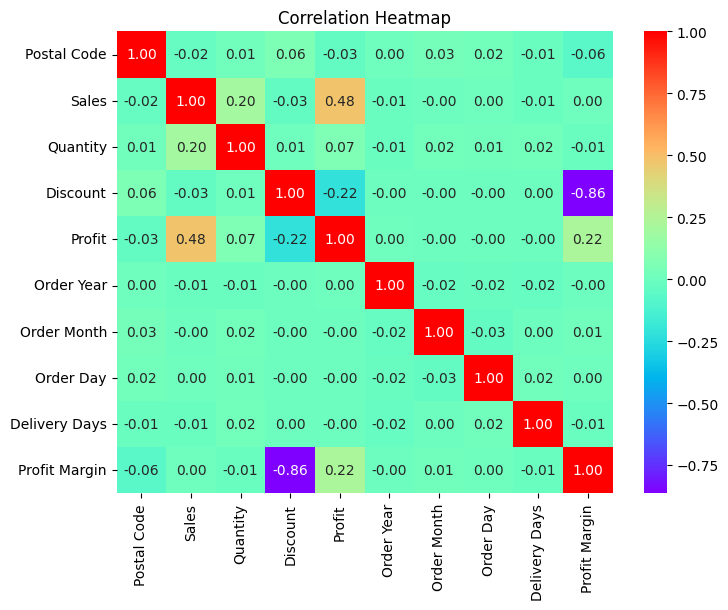

In [ ]:
corr = a.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="rainbow", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
a.dtypes

,0
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object
State,object


In [ ]:
a.to_csv("cleaned_train.csv",index=False)

In [ ]:
a.dtypes

,0
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object
State,object
